#Train YOLOv8 on Tomato_leaf_diseases Dataset

## Toàn bộ quá trình thu thập dữ liệu và train YOLOv8 trên tập dữ liệu lá cà chua


Trỏ vào tập nội dung drive để lấy tập tin cần được giải nén.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Tập tin này chứa tập dữ liệu đã được chia ra để train và test. Dataset được tải về từ Roboflow với 8439 hình ảnh về các loại bệnh đọc từ lá cây cà chua bao gồm:
* Bacterial Spot	1,226 ảnh
* Early Blight	2,147 ảnh
* Healthy	4,333 ảnh
* Iron Deficiency	220 ảnh
* Late Blight	1,460 ảnh
* Leaf Mold	2,099 ảnh
* Leaf_Miner	1,328 ảnh
* Mosaic Virus	660 ảnh
* Septoria	1,492 ảnh
* Spider Mites	1,739 ảnh
* Yellow Leaf Curl Virus 2,274 ảnh

In [ ]:
import zipfile
import os

# 1. Đường dẫn file zip trên Drive
zip_path = '/content/drive/MyDrive/Tomato Project/tomato_data.zip'

# 2. Thư mục đích trên Colab
extract_path = '/content/tomato_dataset'

# 3. Giải nén
print("⏳ Đang giải nén...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Giải nén xong! Kiểm tra thư mục bên trái.")

⏳ Đang giải nén...
✅ Giải nén xong! Kiểm tra thư mục bên trái.


Cấu hình file YAML với các đường dẫn tới tập tin train/val/test + label các bệnh để dễ sử dụng

In [ ]:
import yaml
import os

dataset_root = '/content/tomato_dataset'

# Tạo nội dung data.yaml mới với đường dẫn tuyệt đối
data_content = {
    'train': os.path.join(dataset_root, 'train', 'images'),
    'val':   os.path.join(dataset_root, 'valid', 'images'),
    'test':  os.path.join(dataset_root, 'test', 'images'),

    'nc': 11,
    'names': [
        'Bacterial Spot',
        'Early Blight',
        'Healthy',
        'Iron Deficiency',
        'Late Blight',
        'Leaf Mold',
        'Leaf_Miner',
        'Mosaic Virus',
        'Septoria',
        'Spider Mites',
        'Yellow Leaf Curl Virus'
    ]
}

# Lưu file này ra ngay thư mục gốc của Colab
yaml_path = '/content/tomato_config.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(data_content, f)

print(f"✅ Đã tạo file cấu hình mới tại: {yaml_path}")
print("👉 Đường dẫn train:", data_content['train'])

✅ Đã tạo file cấu hình mới tại: /content/tomato_config.yaml
👉 Đường dẫn train: /content/tomato_dataset/train/images


In [4]:
# Cài đặt thư viện YOLOv8
!pip install ultralytics

Tiến hành train trên YOLO. Vì YOLO có sẵn hàm train và các tham số có thể truyền vào nên ta chỉ cần thêm vào các số liệu và tiến hành bấm nút train.

In [ ]:
from ultralytics import YOLO

# 1. Load model Small
model = YOLO('yolov8s.pt')

print("🚀 Bắt đầu huấn luyện Siêu Model Cà Chua...")

# 2. Train
# data: Trỏ vào file yaml vừa tạo ở Bước 1
# epochs: Với 19k ảnh
results = model.train(
    data='/content/tomato_config.yaml',
    epochs=50,
    imgsz=640,
    patience=10,           # Dừng sớm nếu 10 vòng không tiến bộ
    batch=8,
    project='runs/detect',
    name='tomato_final_v1'
)

🚀 Bắt đầu huấn luyện Siêu Model Cà Chua...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=tomato_final_v12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

Cấu hình thư mục lưu kết quả train

In [ ]:
import os
from IPython.display import Image, display

# --- CẤU HÌNH ---
# Đây là thư mục chứa kết quả train vừa xong
run_folder = '/content/runs/detect/tomato_final_v12'

print(f"✅ Đang trỏ vào thư mục: {run_folder}")

✅ Đang trỏ vào thư mục: /content/runs/detect/tomato_final_v12


📊 1. BIỂU ĐỒ QUÁ TRÌNH HUẤN LUYỆN:


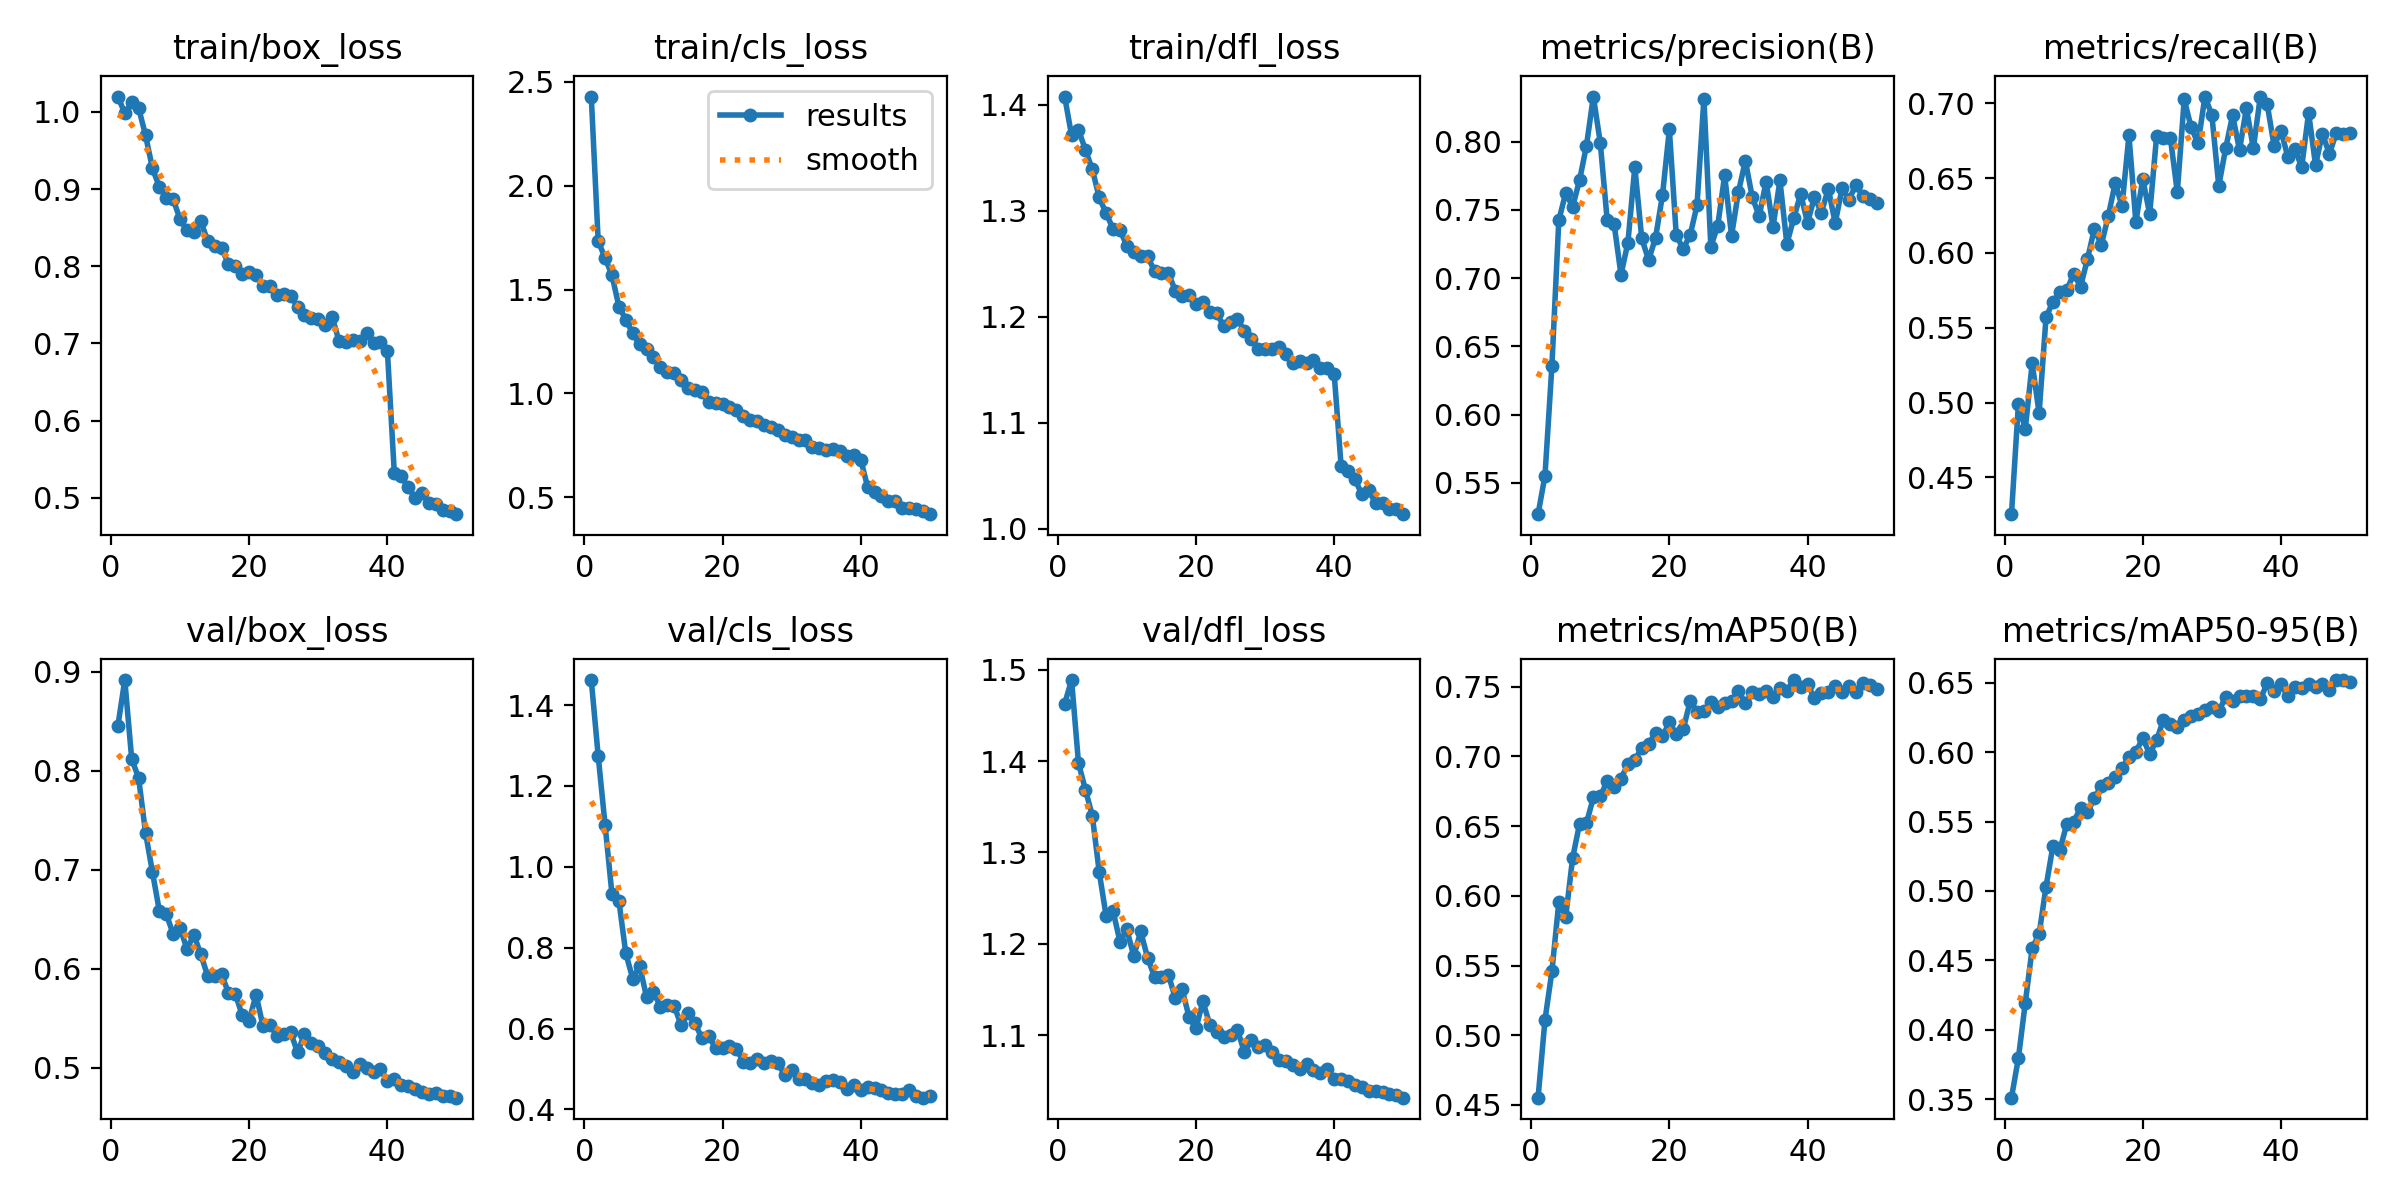

In [ ]:
print("📊 1. BIỂU ĐỒ QUÁ TRÌNH HUẤN LUYỆN:")
results_path = os.path.join(run_folder, 'results.png')

if os.path.exists(results_path):
    display(Image(filename=results_path, width=800))
else:
    print("⚠️ Không tìm thấy file results.png")

😵 2. MA TRẬN NHẦM LẪN (Confusion Matrix):


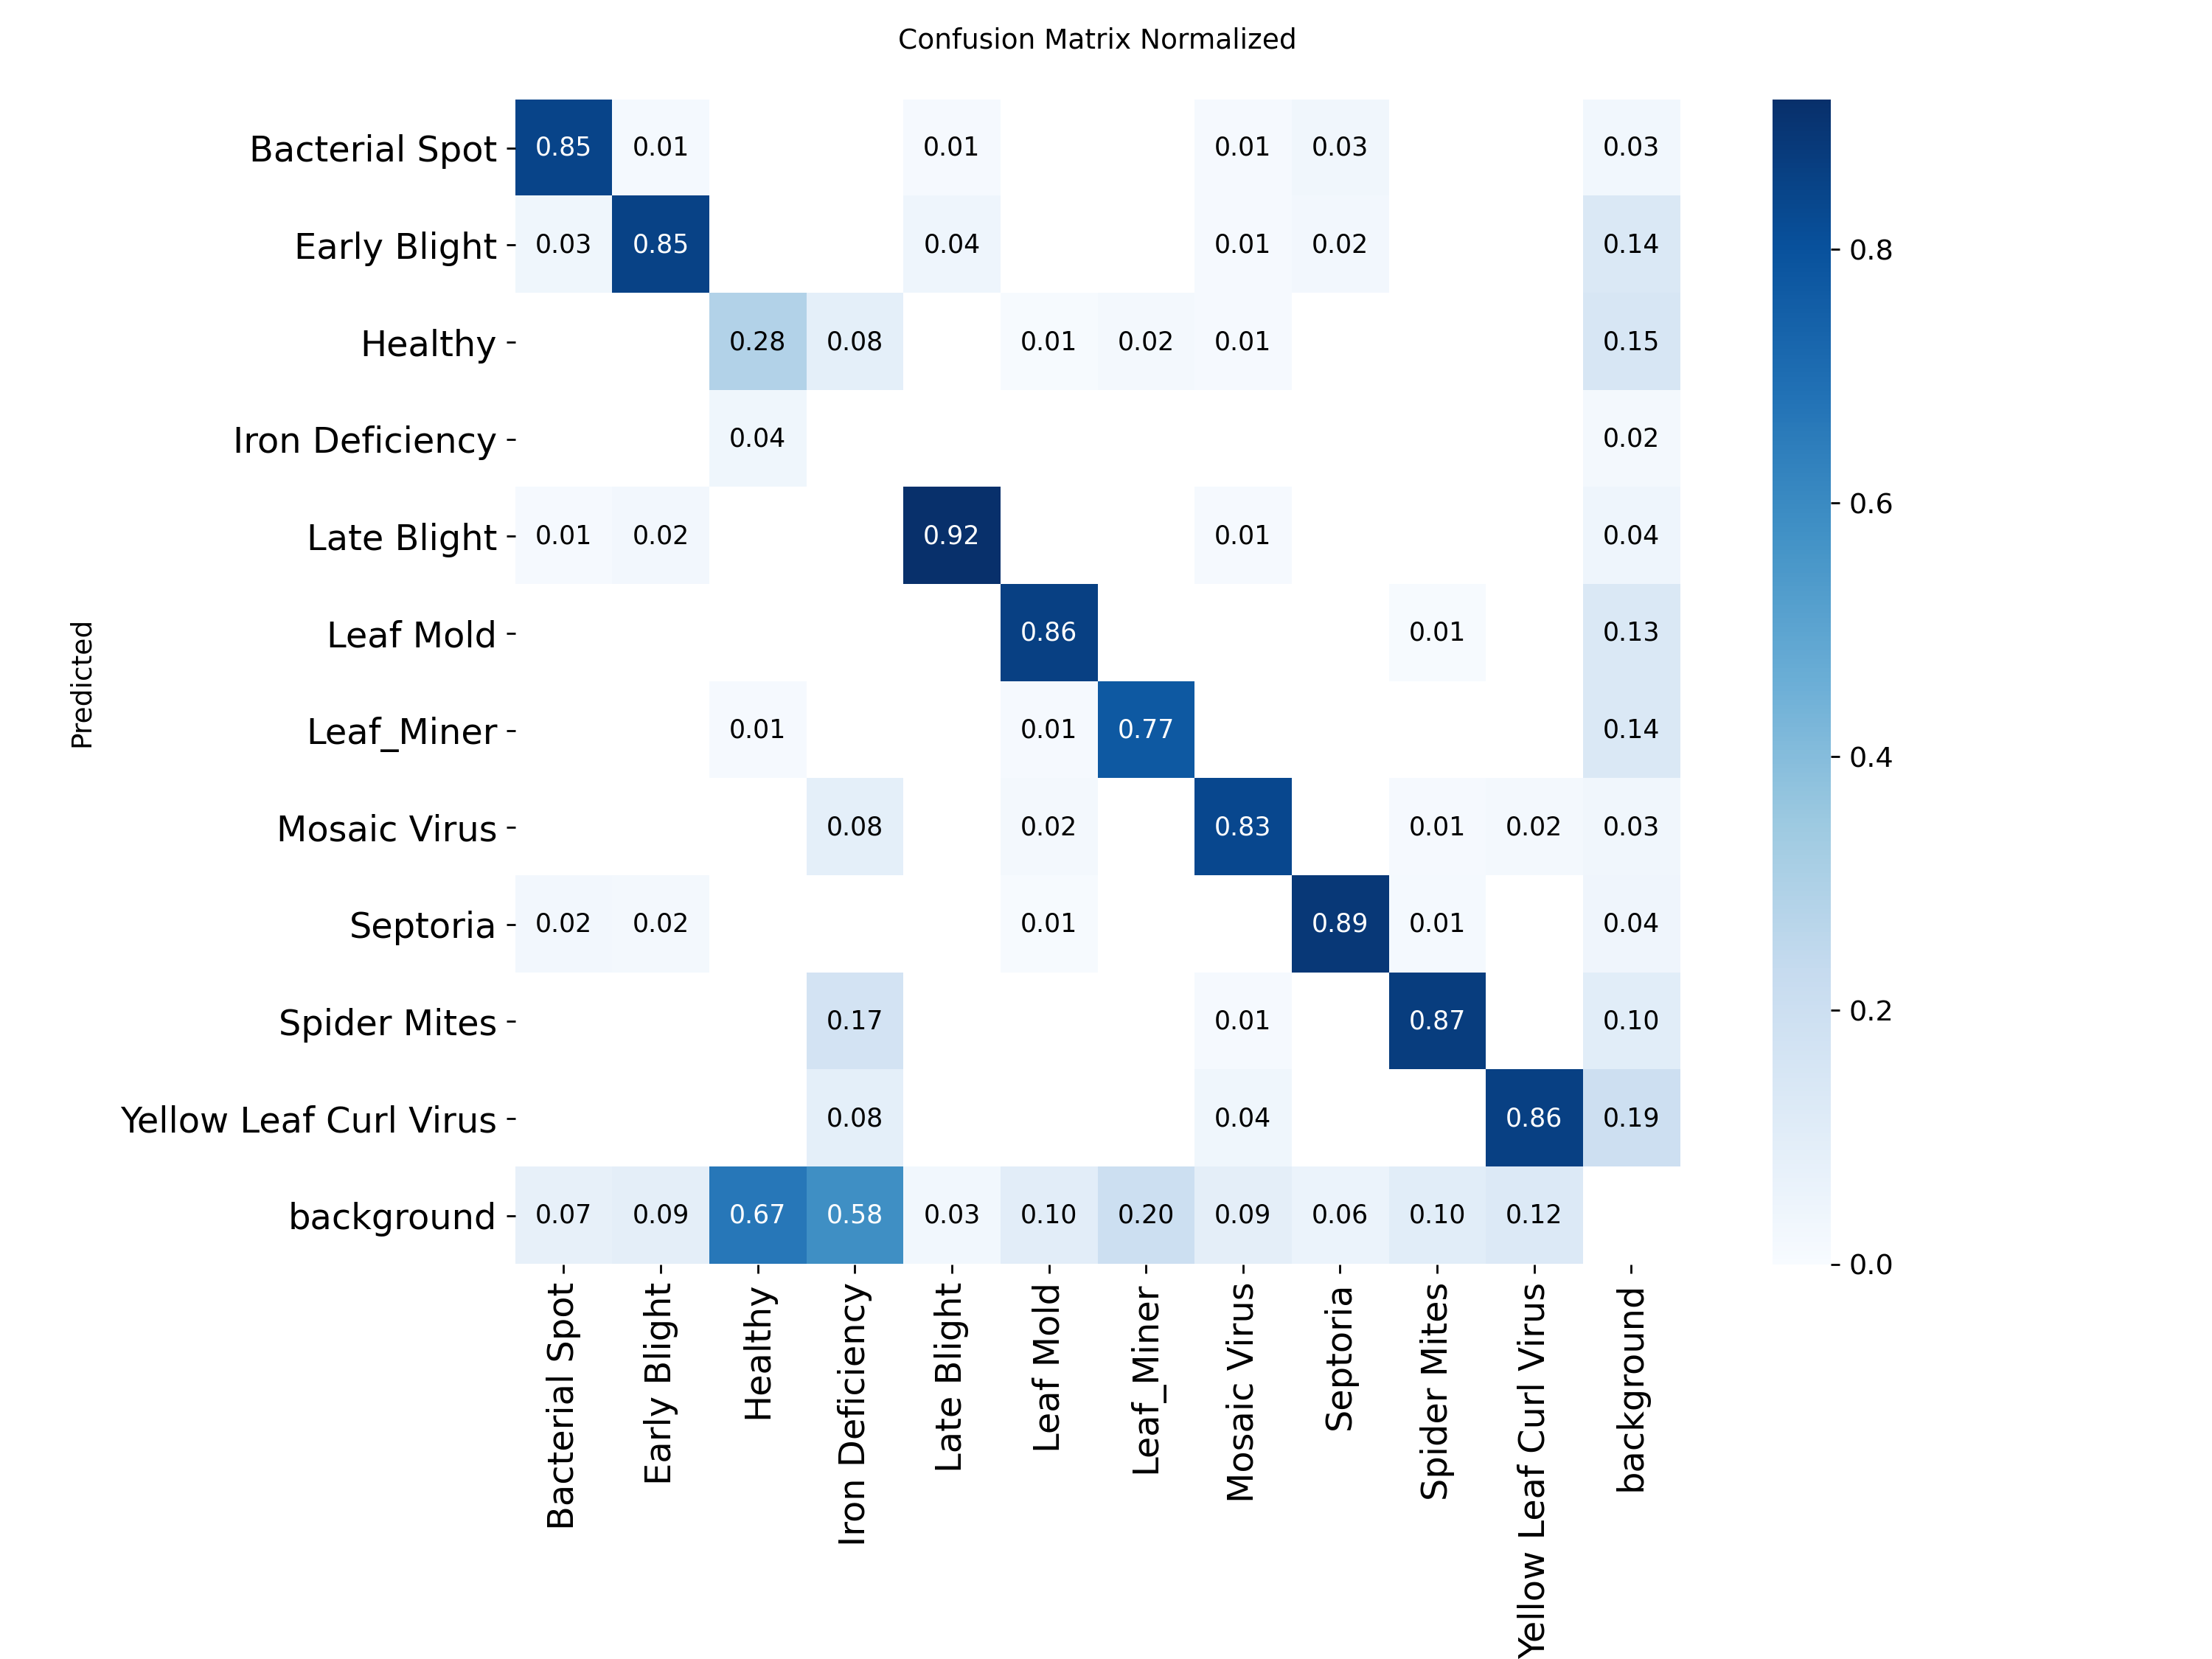

In [ ]:
print("😵 2. MA TRẬN NHẦM LẪN (Confusion Matrix):")

# Ưu tiên xem bản Normalized (%) cho dễ nhìn
conf_matrix = os.path.join(run_folder, 'confusion_matrix_normalized.png')

# Nếu ko có bản % thì xem bản thường
if not os.path.exists(conf_matrix):
    conf_matrix = os.path.join(run_folder, 'confusion_matrix.png')

if os.path.exists(conf_matrix):
    display(Image(filename=conf_matrix, width=800))
else:
    print("⚠️ Không tìm thấy file confusion matrix")

📸 3. SO SÁNH THỰC TẾ:
👆 ẢNH TRÊN: ĐÁP ÁN CHUẨN (Labels)
👇 ẢNH DƯỚI: MÁY DỰ ĐOÁN (Prediction)


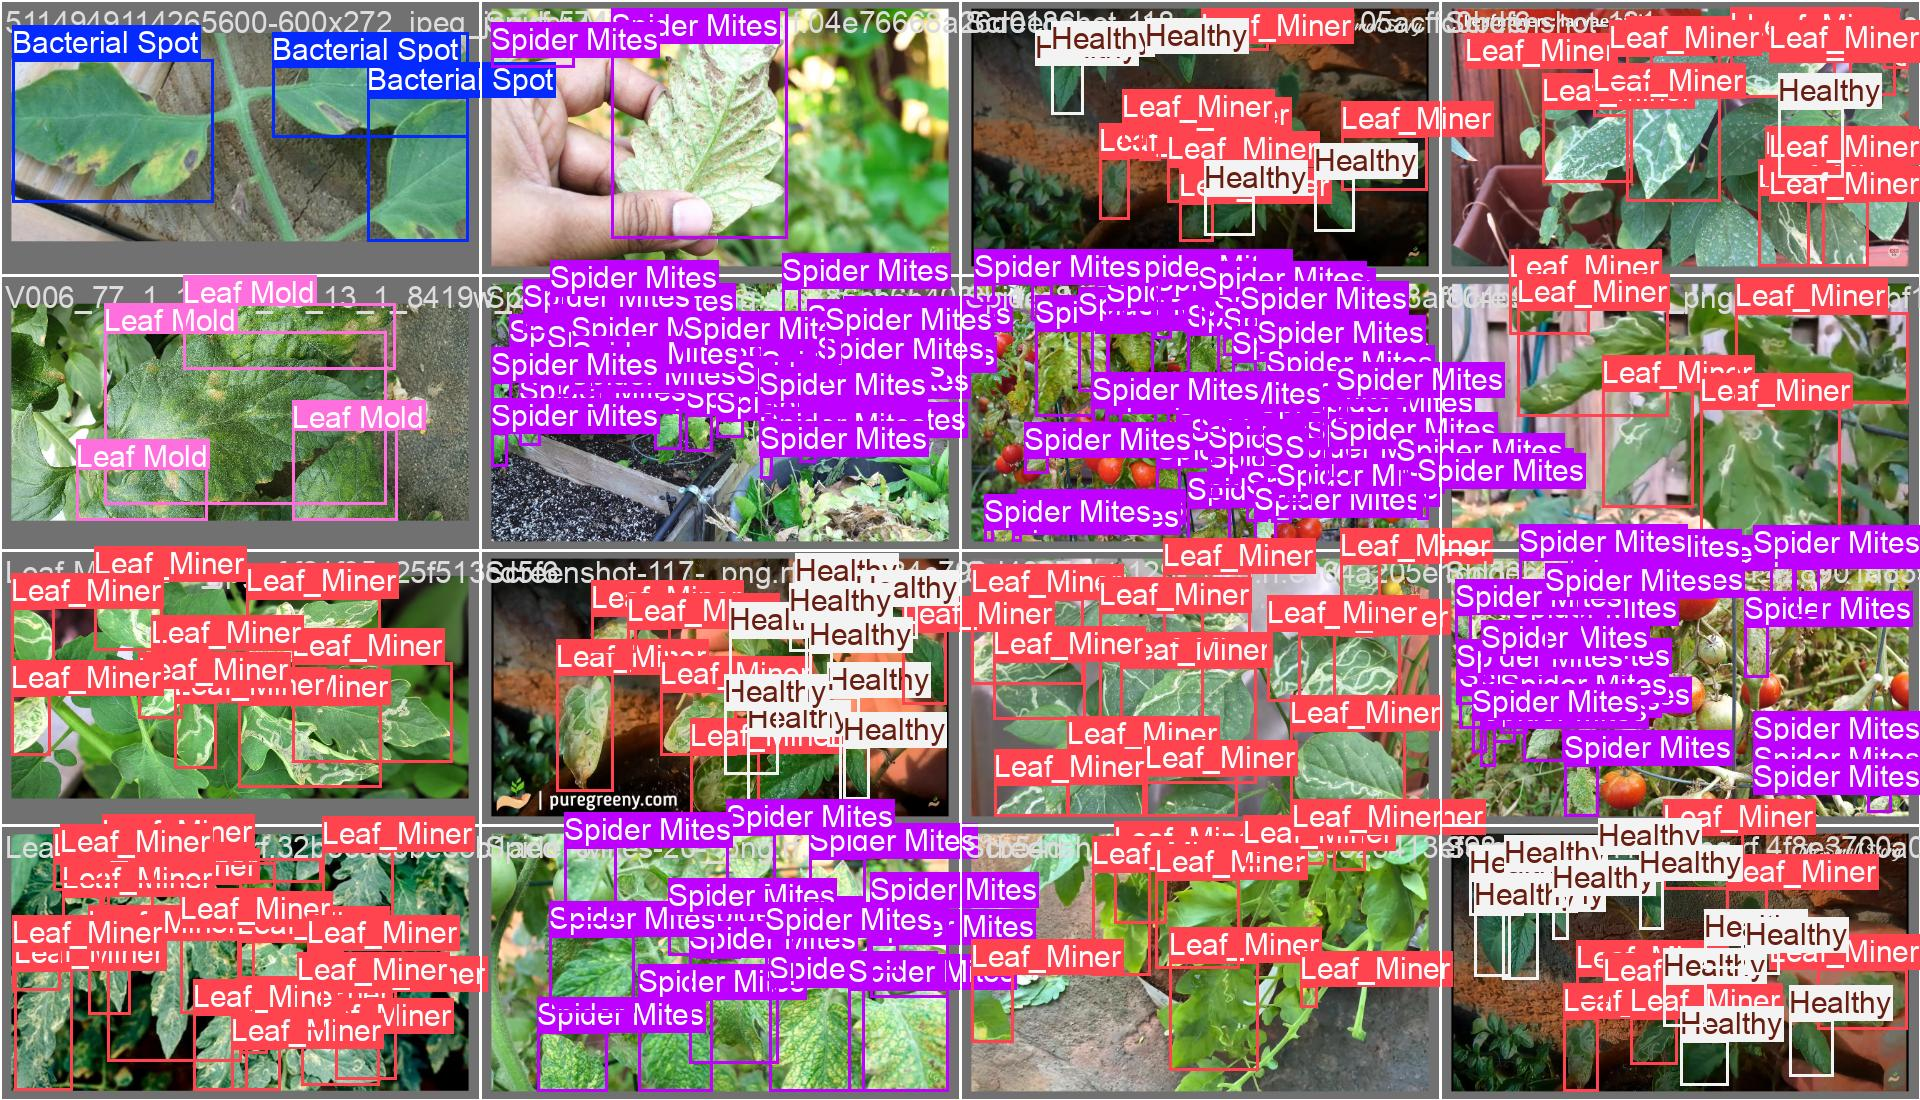

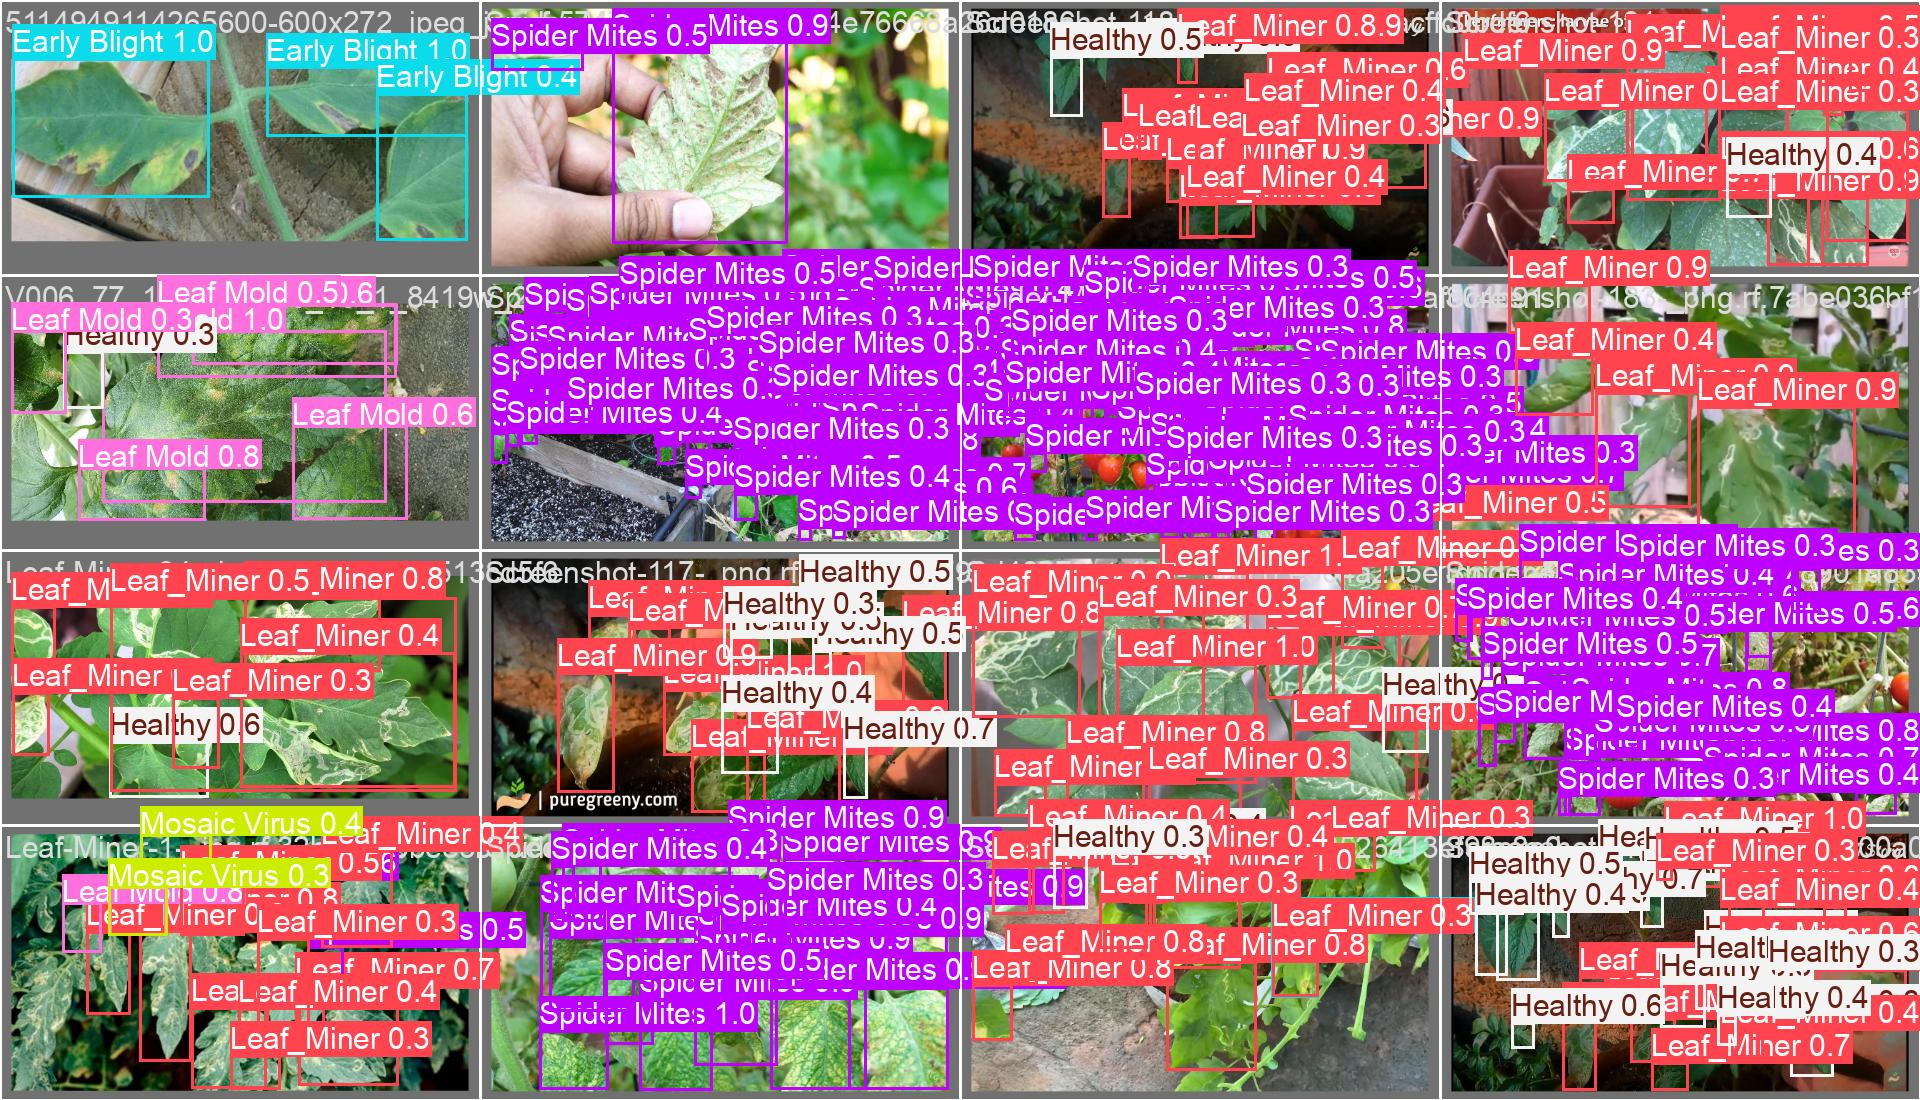

In [ ]:
print("📸 3. SO SÁNH THỰC TẾ:")
print("👆 ẢNH TRÊN: ĐÁP ÁN CHUẨN (Labels)")
print("👇 ẢNH DƯỚI: MÁY DỰ ĐOÁN (Prediction)")

label_batch = os.path.join(run_folder, 'val_batch0_labels.jpg')
pred_batch = os.path.join(run_folder, 'val_batch0_pred.jpg')

if os.path.exists(label_batch) and os.path.exists(pred_batch):
    display(Image(filename=label_batch, width=950)) # Ảnh đáp án
    display(Image(filename=pred_batch, width=950))  # Ảnh máy đoán
else:
    print("⚠️ Không tìm thấy ảnh batch mẫu.")

🎲 4. DEMO CHẠY THỬ TRÊN TẬP TEST:
🖼️ Đang test ảnh: Septoria-Leaf-Spot-103-_JPG.rf.39d4a16629fb664958c59eeaaeae5944.jpg

image 1/1 /content/tomato_dataset/test/images/Septoria-Leaf-Spot-103-_JPG.rf.39d4a16629fb664958c59eeaaeae5944.jpg: 640x640 1 Septoria, 16.3ms
Speed: 3.3ms preprocess, 16.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


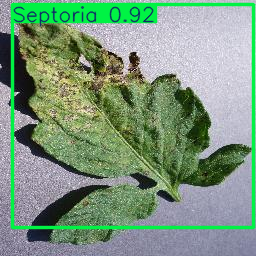

In [ ]:
import glob
import random
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

print("🎲 4. DEMO CHẠY THỬ TRÊN TẬP TEST:")

# 1. Load model best.pt của bạn
model_path = os.path.join(run_folder, 'weights/best.pt')
model = YOLO(model_path)

# 2. Lấy danh sách ảnh test
test_imgs = glob.glob('/content/tomato_dataset/test/images/*.jpg')

if test_imgs:
    # Chọn ngẫu nhiên
    random_file = random.choice(test_imgs)
    print(f"🖼️ Đang test ảnh: {os.path.basename(random_file)}")

    # Dự đoán (Lọc độ tin cậy > 0.4 cho đỡ rác)
    results = model.predict(random_file, conf=0.4)
    res_plotted = results[0].plot()

    # Hiện ảnh
    cv2_imshow(res_plotted)
else:
    print("⚠️ Không tìm thấy ảnh trong thư mục test.")

Sao lưu model để train lần tiếp


In [ ]:
import shutil
import os
from google.colab import drive



# --- CẤU HÌNH ---
# Thư mục chứa kết quả train trên Colab
source_folder = '/content/runs/detect/tomato_final_v12'
destination_folder = '/content/drive/MyDrive/Tomato_Backup/tomato_final_v12'

# 2. Thực hiện Copy
print(f"⏳ Đang sao lưu từ Colab sang Drive...")
print(f"   Nguồn: {source_folder}")
print(f"   Đích:  {destination_folder}")

try:
    if os.path.exists(destination_folder):
        shutil.rmtree(destination_folder)

    # Copy toàn bộ thư mục
    shutil.copytree(source_folder, destination_folder)
    print("✅ SAO LƯU THÀNH CÔNG! Dữ liệu đã an toàn trên Drive.")
    print("👉 Bạn có thể tắt Colab thoải mái. Khi nào cần train tiếp thì vào Drive lấy lại.")

except Exception as e:
    print(f"❌ Lỗi sao lưu: {e}")

⏳ Đang sao lưu từ Colab sang Drive...
   Nguồn: /content/runs/detect/tomato_final_v12
   Đích:  /content/drive/MyDrive/Tomato_Backup/tomato_final_v12
✅ SAO LƯU THÀNH CÔNG! Dữ liệu đã an toàn trên Drive.
👉 Bạn có thể tắt Colab thoải mái. Khi nào cần train tiếp thì vào Drive lấy lại.


Tải và giải nén lại dữ liệu


In [2]:
import os
import zipfile
from google.colab import drive

# 1. Kết nối Google Drive
drive.mount('/content/drive')

# 2. Cài lại thư viện YOLO (Vì máy mới chưa có)
os.system('pip install ultralytics')

# 3. Giải nén lại Dataset từ file Zip trên Drive (Nhanh hơn tải từ mạng)
# (Chỉ làm nếu thư mục dataset chưa tồn tại)
zip_path = '/content/drive/MyDrive/Tomato Project/tomato_data.zip' # File zip gốc
dataset_root = '/content/tomato_dataset'

if not os.path.exists(dataset_root):
    print("⏳ Đang giải nén dữ liệu từ Drive ra Colab...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_root)
        print("✅ Giải nén xong!")
    except:
        print("❌ Lỗi: Không tìm thấy file zip trên Drive. Kiểm tra lại đường dẫn!")
else:
    print("ℹ️ Dữ liệu đã có sẵn.")

# 4. Tạo lại file Config (Cần thiết để train)
import yaml
config_path = '/content/tomato_config.yaml'
data_content = {
    'train': os.path.join(dataset_root, 'train', 'images'),
    'val':   os.path.join(dataset_root, 'valid', 'images'),
    'test':  os.path.join(dataset_root, 'test', 'images'),
    'nc': 11,
    'names': ['Bacterial Spot', 'Early Blight', 'Healthy', 'Iron Deficiency',
              'Late Blight', 'Leaf Mold', 'Leaf_Miner', 'Mosaic Virus',
              'Septoria', 'Spider Mites', 'Yellow Leaf Curl Virus']
}
with open(config_path, 'w') as f:
    yaml.dump(data_content, f)
print("✅ Đã tạo xong file Config.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Đang giải nén dữ liệu từ Drive ra Colab...
✅ Giải nén xong!
✅ Đã tạo xong file Config.


Tiếp tục train


In [6]:
from ultralytics import YOLO

# Trỏ thẳng vào file last.pt bạn đã backup trên Drive
# (Sửa đường dẫn nếu bạn lưu tên khác)
backup_weights = '/content/drive/MyDrive/Tomato_Backup/tomato_final_v12/weights/last.pt'

model = YOLO(backup_weights)

print("🚀 Tiếp tục train từ file Backup trên Drive...")
results = model.train(
    epochs=100
)

🚀 Tiếp tục train từ file Backup trên Drive...
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_config.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Tomato_Backup/tomato_final_v12/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset

KeyboardInterrupt: 

Chạy dự đoán trên ảnh

In [ ]:
from ultralytics import YOLO
import glob
import random
from google.colab.patches import cv2_imshow

# 1. Load model xịn nhất từ Drive
model_path = '/content/drive/MyDrive/Tomato_Backup/tomato_final_v12/weights/best.pt'
model = YOLO(model_path)

# 2. Lấy ảnh test
test_imgs = glob.glob('/content/tomato_dataset/test/images/*.jpg')

if test_imgs:
    # Chọn ngẫu nhiên 1 ảnh
    random_file = random.choice(test_imgs)
    print(f"Testing: {os.path.basename(random_file)}")

    # Dự đoán
    results = model.predict(random_file, conf=0.5)
    cv2_imshow(results[0].plot())

Download model tốt nhất về

In [3]:
from google.colab import files
import os

# Đường dẫn file best.pt
model_path = '/content/runs/detect/tomato_final_v12/weights/best.pt'
if os.path.exists(model_path):
    print("⬇️ Đang tải file best.pt...")
    files.download(model_path)
else:
    print("❌ Không tìm thấy file best.pt. Kiểm tra lại đường dẫn!")

⬇️ Đang tải file best.pt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>